<div style="padding:24px;border-left:8px solid #C99700;background:#071B33;color:white;border-radius:8px">
<h1 style="margin:0">Lab 01 · Monte Carlo, Itô Discretization, and Delta Hedging</h1>
<p style="font-size:17px;margin-bottom:0">A replication claim is tested under numerical error, parameter error, and trading frictions.</p>
</div>

**Research question.** Under Black–Scholes assumptions, how quickly do numerical prices converge—and which risks reappear when the assumptions used by the hedge are wrong?

**Learning objectives.** Distinguish weak from sampling error; construct confidence intervals; quantify variance-reduction efficiency; implement a self-financing discrete hedge; interpret hedging P&L as a model diagnostic.

**Information set.** All experiments are simulated with a fixed seed. No empirical claim is made from synthetic paths.

## 1. Mathematical contract

Under the risk-neutral measure, geometric Brownian motion satisfies

$$dS_t=rS_t\,dt+\sigma S_t\,dW_t,$$

with exact transition

$$S_{t+\Delta}=S_t\exp\!\left((r-\tfrac12\sigma^2)\Delta+\sigma\sqrt{\Delta}Z\right),\qquad Z\sim N(0,1).$$

Itô's lemma applied to $\log S_t$ produces the $-\sigma^2/2$ correction. Euler–Maruyama instead uses $S_{t+\Delta}=S_t+rS_t\Delta+\sigma S_t\sqrt{\Delta}Z$. The exact transition has no time-discretization bias for GBM; Euler generally does.

For a European call, $C_0=e^{-rT}\mathbb E^Q[(S_T-K)^+]$. A Monte Carlo estimator has standard error $s_{\mathrm{payoff}}/\sqrt{N}$, so a 95% interval shrinks only at rate $N^{-1/2}$.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

def find_root():
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / 'utils' / 'quant_models.py').exists():
            return candidate
    raise FileNotFoundError('Repository root not found')

ROOT = find_root()
sys.path.insert(0, str(ROOT))
from utils.quant_models import black_scholes_call, black_scholes_greeks

plt.style.use('seaborn-v0_8-whitegrid')
NAVY, BLUE, GOLD, RED, GREEN = '#071B33', '#1676B8', '#C99700', '#C84C4C', '#26866A'
pd.options.display.float_format = '{:,.6f}'.format
SEED = 20260828
S0, K, r, sigma, T = 100.0, 100.0, 0.03, 0.20, 1.0
analytic = black_scholes_call(S0, K, T, r, sigma)
print(f'Repository: {ROOT.name} | seed: {SEED} | analytic call: {analytic:.6f}')

Repository: Financial_engineering_Lab | seed: 20260828 | analytic call: 9.413403


## 2. Weak discretization error is not Monte Carlo error

Both errors are present in an Euler estimate. To separate them, the same Gaussian paths drive exact and Euler terminal values. Their paired difference estimates discretization bias with much lower noise.

,dt,exact_MC_error,Euler_minus_exact,paired_SE,Euler_price
steps,,,,,
1,1.000000,-0.029244,-0.125446,0.006963,9.258713
2,0.500000,-0.061249,-0.023264,0.004694,9.328891
4,0.250000,-0.050279,-0.003259,0.003330,9.359866
12,0.083333,0.015917,0.001149,0.001961,9.430470
52,0.019231,0.065506,0.000091,0.000943,9.479000
252,0.003968,0.006674,0.000363,0.000430,9.420441


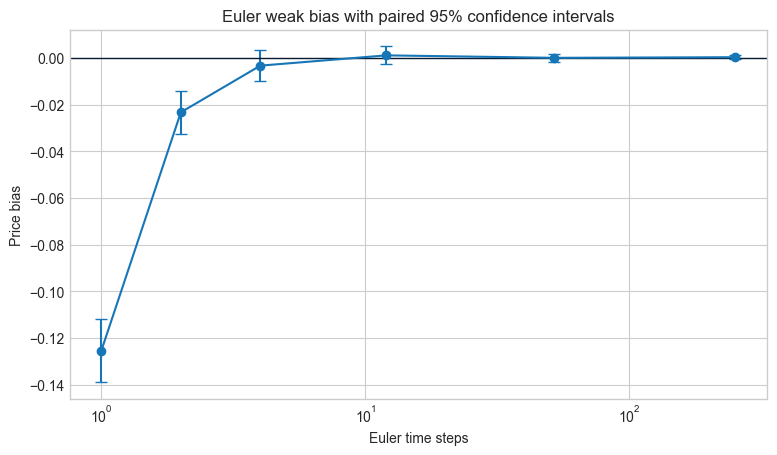

In [2]:
rng = np.random.default_rng(SEED)
n_paths = 120_000
rows = []
for steps in [1, 2, 4, 12, 52, 252]:
    dt = T / steps
    z = rng.standard_normal((n_paths, steps))
    exact_terminal = S0 * np.exp(np.sum((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z, axis=1))
    euler_terminal = np.full(n_paths, S0)
    for j in range(steps):
        euler_terminal *= 1 + r * dt + sigma * np.sqrt(dt) * z[:, j]
    exact_payoff = np.exp(-r*T) * np.maximum(exact_terminal - K, 0)
    euler_payoff = np.exp(-r*T) * np.maximum(euler_terminal - K, 0)
    paired = euler_payoff - exact_payoff
    rows.append({
        'steps': steps, 'dt': dt,
        'exact_MC_error': exact_payoff.mean() - analytic,
        'Euler_minus_exact': paired.mean(),
        'paired_SE': paired.std(ddof=1) / np.sqrt(n_paths),
        'Euler_price': euler_payoff.mean()
    })
discretization = pd.DataFrame(rows).set_index('steps')
display(discretization)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.errorbar(discretization.index, discretization['Euler_minus_exact'],
            yerr=1.96*discretization['paired_SE'], marker='o', color=BLUE, capsize=4)
ax.axhline(0, color=NAVY, linewidth=1)
ax.set(xscale='log', xlabel='Euler time steps', ylabel='Price bias',
       title='Euler weak bias with paired 95% confidence intervals')
plt.show()

## 3. Variance reduction as an efficiency calculation

Antithetic sampling averages payoffs generated by $Z$ and $-Z$. A control variate uses $S_T$, whose risk-neutral expectation $S_0e^{rT}$ is known. With $Y$ the discounted payoff and $X=S_T$,

$$Y^{cv}=Y-\beta(X-\mathbb E[X]),\qquad \beta^*=\frac{\operatorname{Cov}(Y,X)}{\operatorname{Var}(X)}.$$

The relevant score is not merely a smaller standard error, but **variance-reduction ratio at equal simulation cost**.

In [3]:
rng = np.random.default_rng(SEED + 1)
pairs = 100_000
z = rng.standard_normal(pairs)
st_plus = S0*np.exp((r-.5*sigma**2)*T + sigma*np.sqrt(T)*z)
st_minus = S0*np.exp((r-.5*sigma**2)*T - sigma*np.sqrt(T)*z)
disc = np.exp(-r*T)
pay_plus = disc*np.maximum(st_plus-K, 0)
pay_minus = disc*np.maximum(st_minus-K, 0)
plain = np.r_[pay_plus, pay_minus]
antithetic = 0.5*(pay_plus + pay_minus)
control_x = 0.5*(st_plus + st_minus)
beta = np.cov(antithetic, control_x, ddof=1)[0, 1] / np.var(control_x, ddof=1)
controlled = antithetic - beta*(control_x - S0*np.exp(r*T))

def estimator_row(name, samples, effective_draws):
    se = samples.std(ddof=1)/np.sqrt(len(samples))
    return {'estimator': name, 'price': samples.mean(), 'bias': samples.mean()-analytic,
            'standard_error': se, 'CI_low': samples.mean()-1.96*se,
            'CI_high': samples.mean()+1.96*se, 'normal_draws': effective_draws}

vr = pd.DataFrame([
    estimator_row('Plain', plain, 2*pairs),
    estimator_row('Antithetic', antithetic, 2*pairs),
    estimator_row('Antithetic + control', controlled, 2*pairs),
]).set_index('estimator')
vr['variance_ratio_vs_plain'] = (vr.loc['Plain','standard_error']/vr['standard_error'])**2
display(vr)
print(f'Estimated optimal control coefficient: {beta:.6f}')

,price,bias,standard_error,CI_low,CI_high,normal_draws,variance_ratio_vs_plain
estimator,,,,,,,
Plain,9.427466,0.014062,0.031583,9.365563,9.489368,200000,1.000000
Antithetic,9.427466,0.014062,0.023521,9.381365,9.473566,200000,1.803033
Antithetic + control,9.417503,0.004099,0.006502,9.404759,9.430246,200000,23.595461


Estimated optimal control coefficient: 2.447555


## 4. Discrete self-financing replication

In continuous time with the correct diffusion, the Black–Scholes delta $\Delta_t=N(d_1)$ eliminates the $dW_t$ exposure. In discrete time the hedge error remains random. If the hedge volatility differs from realized volatility, or trading costs are charged, rebalancing faster need not improve net P&L.

The experiment below starts with the model price, finances stock purchases through the cash account, accrues cash at $r$, and charges proportional cost on every rebalance. Terminal error is replication wealth minus the option payoff.

scenario,correct + 5 bps costs,correct model,volatility understated
rebalances,,,
4,-0.046615,-0.021152,-2.021634
12,-0.039007,0.013155,-1.984851
52,-0.115494,-0.001811,-1.996263
252,-0.247841,0.003686,-1.986132


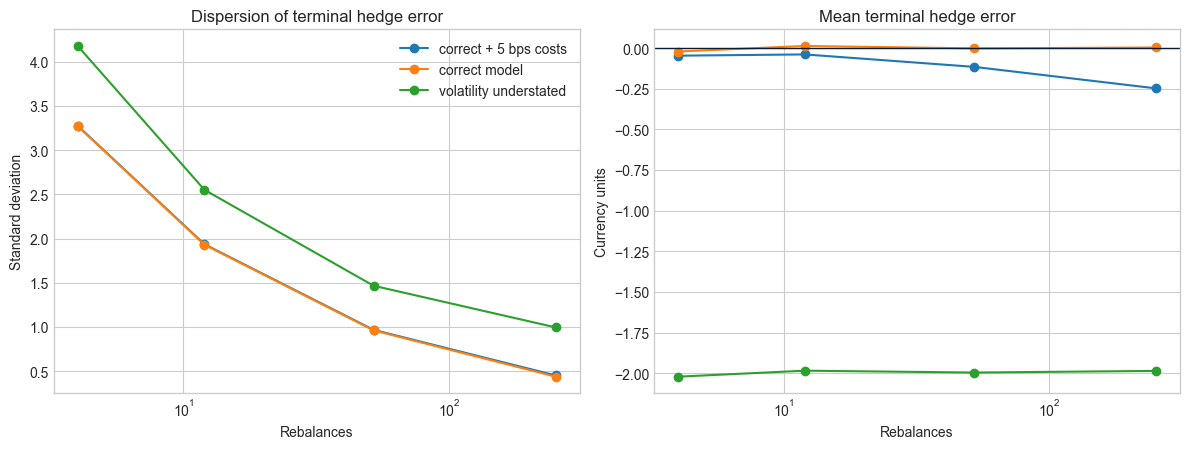

In [4]:
def bs_delta(spot, strike, rate, vol, tau):
    tau = np.maximum(tau, 1e-12)
    d1 = (np.log(spot/strike) + (rate + .5*vol**2)*tau)/(vol*np.sqrt(tau))
    return norm.cdf(d1)

def hedge_errors(steps, true_vol, hedge_vol, cost_bps=0.0, paths=30_000, seed=0):
    rng = np.random.default_rng(seed)
    dt = T/steps
    z = rng.standard_normal((paths, steps))
    stock = np.empty((paths, steps+1)); stock[:, 0] = S0
    for i in range(steps):
        stock[:, i+1] = stock[:, i]*np.exp((r-.5*true_vol**2)*dt + true_vol*np.sqrt(dt)*z[:, i])
    option_cash = black_scholes_call(S0, K, T, r, hedge_vol)
    delta = np.full(paths, bs_delta(S0, K, r, hedge_vol, T))
    cash = np.full(paths, option_cash) - delta*S0
    total_cost = np.zeros(paths)
    for i in range(1, steps):
        cash *= np.exp(r*dt)
        new_delta = bs_delta(stock[:, i], K, r, hedge_vol, T-i*dt)
        traded = np.abs(new_delta-delta)*stock[:, i]
        fee = cost_bps*1e-4*traded
        cash -= (new_delta-delta)*stock[:, i] + fee
        total_cost += fee
        delta = new_delta
    cash *= np.exp(r*dt)
    portfolio = delta*stock[:, -1] + cash
    payoff = np.maximum(stock[:, -1]-K, 0)
    return portfolio-payoff, total_cost

scenarios = []
for steps in [4, 12, 52, 252]:
    for label, true_vol, hedge_vol, fee in [
        ('correct model', .20, .20, 0),
        ('volatility understated', .25, .20, 0),
        ('correct + 5 bps costs', .20, .20, 5),
    ]:
        error, costs = hedge_errors(steps, true_vol, hedge_vol, fee, seed=SEED+steps)
        scenarios.append({'rebalances': steps, 'scenario': label,
                          'mean_error': error.mean(), 'error_std': error.std(ddof=1),
                          'q01': np.quantile(error,.01), 'q99': np.quantile(error,.99),
                          'mean_cost': costs.mean()})
hedging = pd.DataFrame(scenarios)
display(hedging.pivot(index='rebalances', columns='scenario', values='mean_error'))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for label, group in hedging.groupby('scenario'):
    axes[0].plot(group.rebalances, group.error_std, marker='o', label=label)
    axes[1].plot(group.rebalances, group.mean_error, marker='o', label=label)
axes[0].set(xscale='log', title='Dispersion of terminal hedge error', xlabel='Rebalances', ylabel='Standard deviation')
axes[1].set(xscale='log', title='Mean terminal hedge error', xlabel='Rebalances', ylabel='Currency units')
axes[1].axhline(0, color=NAVY, linewidth=1)
axes[0].legend(frameon=False)
plt.tight_layout(); plt.show()

## 5. Research conclusion and model-risk register

- Exact GBM simulation removes time-step bias, but not finite-sample uncertainty. A price without an error bar is incomplete.
- Antithetic and control variates exploit known structure; their value is measurable as variance reduction per random draw.
- Under the correct frictionless model, hedge-error dispersion contracts as trading becomes finer. Understating volatility creates a systematic shortfall because the option was underfunded.
- Transaction costs create a bias that worsens with more frequent rebalancing. Continuous replication is therefore a limiting theorem, not a literal trading recipe.

> **What this notebook does not prove.** GBM adequacy, constant volatility, continuous liquidity, or the absence of jumps. The experiment validates an implementation against a controlled data-generating process.

### Extensions

1. Replace GBM by Merton jump diffusion and decompose hedge error by jump arrival.
2. Compare Euler, Milstein, and exact schemes for path-dependent claims.
3. Optimize the rebalance threshold under a specified cost and risk-aversion functional.
4. Derive and test the delta–gamma approximation $dV\approx\Delta\,dS+\tfrac12\Gamma(dS)^2+\Theta\,dt$.